# 가변밀도 샘플링(VDS) 마스크 — Lustig SparseMRI 포팅

`mrrecon/data/masks.py`의 언더샘플링 마스크를 시각화합니다. 특히 **Lustig SparseMRI**의 가변밀도 샘플링(Lustig, Donoho, Pauly, *Sparse MRI*, MRM 2007)에 초점을 둡니다.

1. **`genPDF`** — 가변밀도 샘플링 **확률** `pdf(k) = (1-|k|)^p + α` 를 만듭니다. `[0,1]`로 clip하고 중앙 ACS는 1로 강제하며, α는 **기대 샘플 수 = `pctg·N`** 이 되도록 이분탐색으로 찾습니다.
2. **`genSampling`** — 몬테카를로: PDF에서 이진 마스크를 **여러 번 뽑아**, **peak interference `max|ifft(mask/pdf)|` 가 가장 낮은(= 가장 incoherent한)** 마스크를 채택합니다.

기존의 단순한 `random` / `gaussian1d` / `vds` 패턴과 비교합니다 (1D Cartesian 위상인코딩, 중앙 ACS는 fully-sampled).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import numpy as np
import matplotlib.pyplot as plt
from mrrecon.data.masks import undersampling_mask, gen_pdf_1d, gen_sampling_1d

W, ACC, ACS = 320, 4, 24          # phase-encode width, acceleration, ACS lines
print(f'W={W}  acc={ACC}x  acs={ACS}  target samples ~= {W//ACC}')

W=320  acc=4x  acs=24  target samples ~= 80


## 1. `genPDF` — 가변밀도 확률

다항식 차수 `p`가 클수록 샘플링 확률이 k-space **중심에 더 집중**됩니다. 이분탐색으로 상수 `α`를 더해, PDF 아래 면적(= 기대 샘플 수)이 샘플 예산과 같아지도록 맞춥니다.

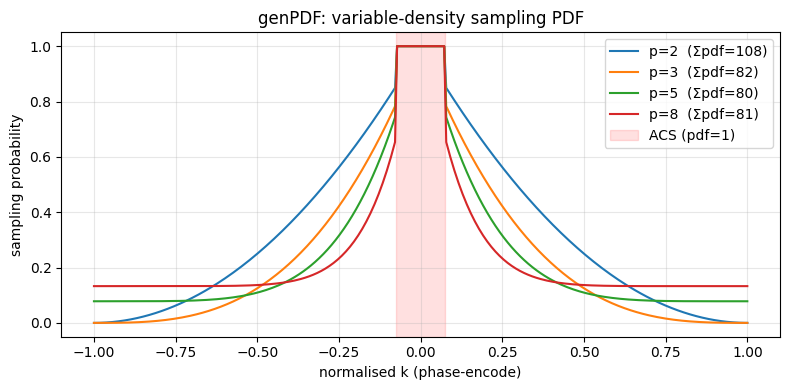

In [2]:
ks = np.linspace(-1, 1, W)
plt.figure(figsize=(8,4))
for p in [2, 3, 5, 8]:
    pdf = gen_pdf_1d(W, p=p, pctg=1/ACC, radius=ACS/W)
    plt.plot(ks, pdf, label=f'p={p}  (Σpdf={pdf.sum():.0f})')
plt.axvspan(-ACS/W, ACS/W, color='red', alpha=0.12, label='ACS (pdf=1)')
plt.xlabel('normalised k (phase-encode)'); plt.ylabel('sampling probability')
plt.title('genPDF: variable-density sampling PDF'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. `genSampling` — 몬테카를로 비간섭성 최적화

고정된 PDF에 대해, **변환 점확산함수(point-spread function)** `ifft(mask/pdf)` 는 aliasing이 얼마나 coherent한지를 알려줍니다. off-DC peak가 낮을수록 = **잡음 같은(좋은) aliasing** 입니다. `genSampling`은 무작위 추출을 여러 번 시도해 그중 **가장 좋은 것**을 채택합니다.

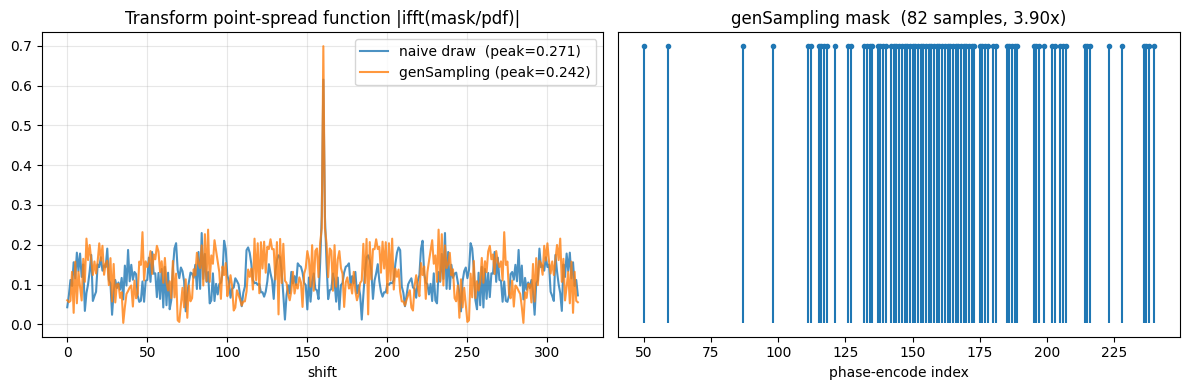

peak sidelobe: naive 0.2707  ->  genSampling 0.2416  (11% lower)


In [3]:
pdf = gen_pdf_1d(W, p=3, pctg=1/ACC, radius=ACS/W)
rng = np.random.default_rng(0)

# a single naive random draw vs the genSampling-optimised draw
naive = (rng.random(W) < pdf).astype(float)
best  = gen_sampling_1d(pdf, n_iter=200, rng=np.random.default_rng(0))

def psf_peak(mask):
    TMP = np.fft.ifft(mask / np.clip(pdf, 1e-6, 1))
    return np.abs(TMP), float(np.max(np.abs(TMP[1:])))

psf_n, peak_n = psf_peak(naive)
psf_b, peak_b = psf_peak(best)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(np.fft.fftshift(psf_n), label=f'naive draw  (peak={peak_n:.3f})', alpha=0.8)
ax[0].plot(np.fft.fftshift(psf_b), label=f'genSampling (peak={peak_b:.3f})', alpha=0.8)
ax[0].set_title('Transform point-spread function |ifft(mask/pdf)|')
ax[0].set_xlabel('shift'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].stem(np.where(best>0)[0], np.ones((best>0).sum()), basefmt=' ', markerfmt='.')
ax[1].set_title(f'genSampling mask  ({int(best.sum())} samples, {W/best.sum():.2f}x)')
ax[1].set_xlabel('phase-encode index'); ax[1].set_yticks([])
plt.tight_layout(); plt.show()
print(f'peak sidelobe: naive {peak_n:.4f}  ->  genSampling {peak_b:.4f}  '
      f'({100*(peak_n-peak_b)/peak_n:.0f}% lower)')

## 3. 모든 마스크 종류 한눈에 비교

`random`(균일 외곽) · `gaussian1d`(∝exp(-4|k|)) · `vds`(∝(1-|k|)^p, 정확한 개수) · `vds_lustig`(genPDF+genSampling, 비간섭성 최적화).

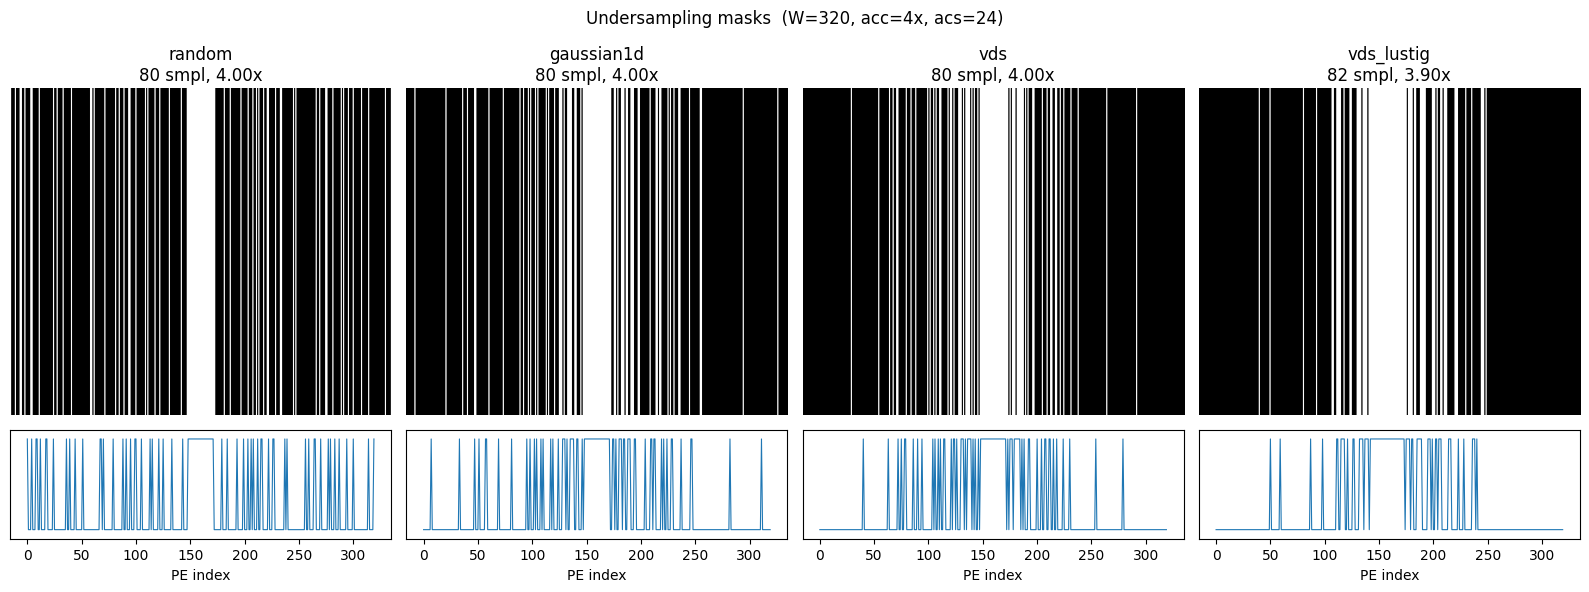

In [4]:
types = ['random', 'gaussian1d', 'vds', 'vds_lustig']
fig, axes = plt.subplots(2, len(types), figsize=(4*len(types), 6),
                         gridspec_kw={'height_ratios':[3,1]})
for j, mt in enumerate(types):
    m = undersampling_mask((W, W), ACC, ACS, mask_type=mt,
                           rng=np.random.default_rng(0), vds_power=3.0)
    line = m[0]
    axes[0,j].imshow(m, cmap='gray', aspect='auto')
    axes[0,j].set_title(f'{mt}\n{int(line.sum())} smpl, {W/line.sum():.2f}x')
    axes[0,j].axis('off')
    axes[1,j].plot(line, lw=0.8); axes[1,j].set_ylim(-0.1,1.1)
    axes[1,j].set_yticks([]); axes[1,j].set_xlabel('PE index')
plt.suptitle(f'Undersampling masks  (W={W}, acc={ACC}x, acs={ACS})')
plt.tight_layout(); plt.show()

## 4. 비간섭성: `vds` vs `vds_lustig`

다항식 밀도는 같지만, `vds_lustig`는 추가로 점확산함수의 **peak 사이드로브를 최소화**합니다. peak가 낮을수록 = aliasing이 더 잡음 같아(incoherent) CS 이론이 원하는 형태가 됩니다.

mean peak sidelobe   vds=0.4927   vds_lustig=0.2513   (49% lower)


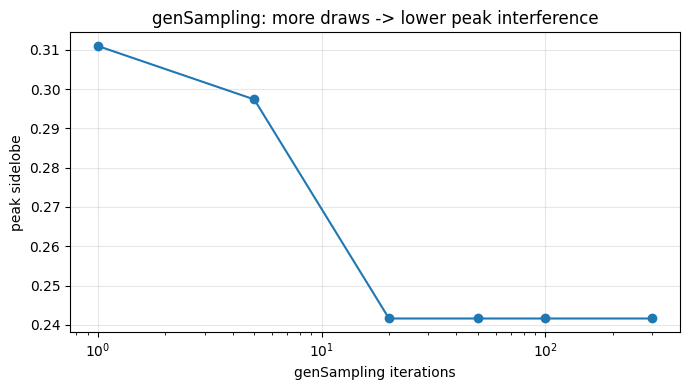

In [5]:
pdf = gen_pdf_1d(W, p=3, pctg=1/ACC, radius=ACS/W)
def peak_of(mask):
    return float(np.max(np.abs(np.fft.ifft(mask / np.clip(pdf,1e-6,1))[1:])))

# average peak sidelobe over several seeds
vds_peaks, lus_peaks = [], []
for s in range(8):
    mv = undersampling_mask((1,W), ACC, ACS, 'vds', np.random.default_rng(s), 3.0)[0]
    ml = undersampling_mask((1,W), ACC, ACS, 'vds_lustig', np.random.default_rng(s), 3.0)[0]
    vds_peaks.append(peak_of(mv)); lus_peaks.append(peak_of(ml))
print(f'mean peak sidelobe   vds={np.mean(vds_peaks):.4f}   '
      f'vds_lustig={np.mean(lus_peaks):.4f}   '
      f'({100*(1-np.mean(lus_peaks)/np.mean(vds_peaks)):.0f}% lower)')

# peak sidelobe vs number of Monte-Carlo iterations
iters = [1, 5, 20, 50, 100, 300]
peaks = [peak_of(gen_sampling_1d(pdf, n_iter=it, rng=np.random.default_rng(0))) for it in iters]
plt.figure(figsize=(7,4))
plt.plot(iters, peaks, 'o-')
plt.xscale('log'); plt.xlabel('genSampling iterations'); plt.ylabel('peak sidelobe')
plt.title('genSampling: more draws -> lower peak interference'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. 기존 `vds`와 무엇이 달라졌나

다항식 *밀도*는 같지만 *샘플링 방식*이 다릅니다. 구체적 차이 3가지:

| | 기존 `vds` | `vds_lustig` |
|---|---|---|
| **pdf** | `(1-\|k\|)^p`, 외곽에서 0으로 | `(1-\|k\|)^p + α` (이분탐색 α), 외곽에 **floor** 유지 |
| **정규화** | 외곽 컬럼 합 = 고정 개수 | 각 컬럼이 `[0,1]` 확률, Σ = W/acc |
| **추출** | `choice(replace=False)` → **정확한** 개수 | Bernoulli `rand<pdf` → **무작위** 개수 |
| **비간섭성** | 단일 draw, 최적화 없음 | 몬테카를로, peak-sidelobe 최소 draw 채택 |

아래: (a) 컬럼별 실제 샘플링 확률, (b) 샘플 개수 분포, (c) 원시 마스크 변환 PSF `|ifft(mask)|`.

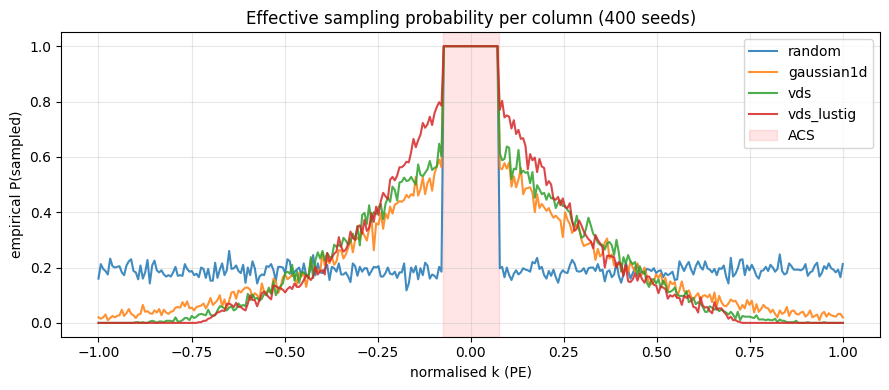

note: vds drops to ~0 at the edges; vds_lustig keeps a small floor (alpha) -> better high-frequency tail coverage


In [6]:
# (a) empirical P(sampled) per phase-encode column, averaged over many seeds
def empirical_prob(mt, seeds=400, power=3.0):
    acc = np.zeros(W)
    for s in range(seeds):
        acc += undersampling_mask((1, W), ACC, ACS, mt,
                                  np.random.default_rng(s), power)[0]
    return acc / seeds

ksn = np.linspace(-1, 1, W)
plt.figure(figsize=(9,4))
for mt in ['random', 'gaussian1d', 'vds', 'vds_lustig']:
    plt.plot(ksn, empirical_prob(mt), label=mt, alpha=0.85)
plt.axvspan(-ACS/W, ACS/W, color='red', alpha=0.10, label='ACS')
plt.xlabel('normalised k (PE)'); plt.ylabel('empirical P(sampled)')
plt.title('Effective sampling probability per column (400 seeds)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('note: vds drops to ~0 at the edges; vds_lustig keeps a small floor (alpha) '
      '-> better high-frequency tail coverage')

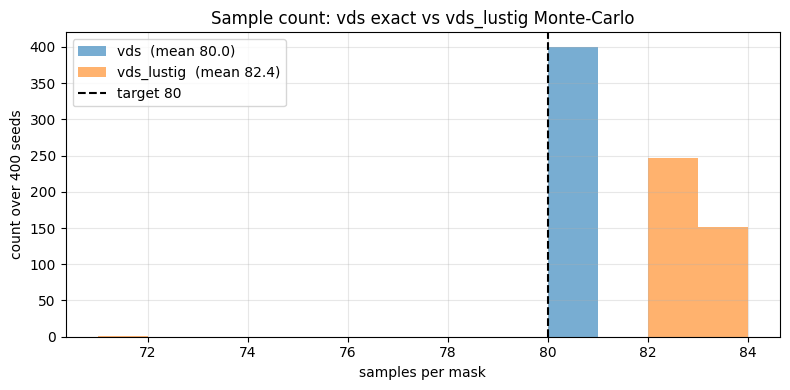

In [7]:
# (b) sample-count distribution: vds is exact, vds_lustig is Monte-Carlo (spread)
cnt_vds = [int(undersampling_mask((1,W),ACC,ACS,'vds',np.random.default_rng(s),3)[0].sum())
           for s in range(400)]
cnt_lus = [int(undersampling_mask((1,W),ACC,ACS,'vds_lustig',np.random.default_rng(s),3)[0].sum())
           for s in range(400)]
plt.figure(figsize=(8,4))
plt.hist(cnt_vds, bins=range(min(cnt_vds+cnt_lus), max(cnt_vds+cnt_lus)+2),
         alpha=0.6, label=f'vds  (mean {np.mean(cnt_vds):.1f})')
plt.hist(cnt_lus, bins=range(min(cnt_vds+cnt_lus), max(cnt_vds+cnt_lus)+2),
         alpha=0.6, label=f'vds_lustig  (mean {np.mean(cnt_lus):.1f})')
plt.axvline(W/ACC, color='k', ls='--', label=f'target {W//ACC}')
plt.xlabel('samples per mask'); plt.ylabel('count over 400 seeds')
plt.title('Sample count: vds exact vs vds_lustig Monte-Carlo')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

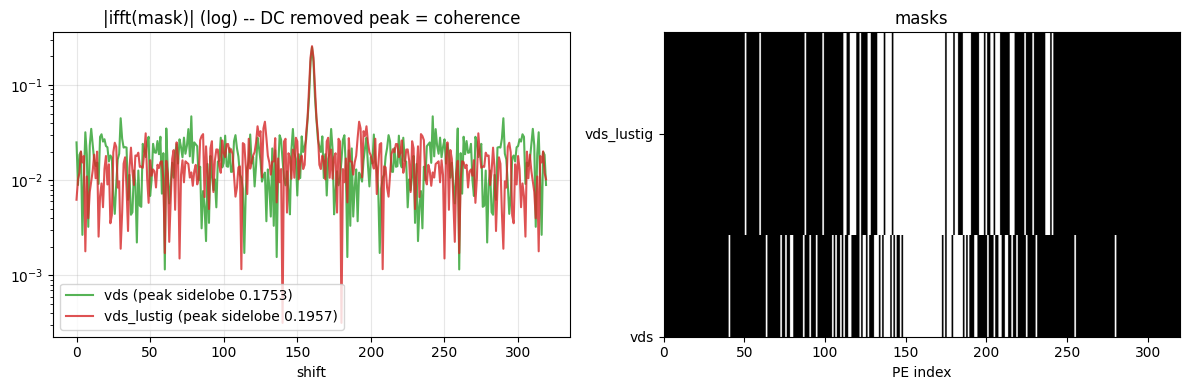

In [8]:
# (c) raw transform point-spread |ifft(mask)| (centred) -- lower off-DC peak = more incoherent
fig, ax = plt.subplots(1, 2, figsize=(12,4))
for mt, col in [('vds','C2'), ('vds_lustig','C3')]:
    m = undersampling_mask((1,W),ACC,ACS,mt,np.random.default_rng(0),3)[0]
    psf = np.abs(np.fft.fftshift(np.fft.ifft(m)))
    peak = psf.copy(); peak[len(peak)//2] = 0           # zero the DC (mainlobe)
    ax[0].plot(psf, col, label=f'{mt} (peak sidelobe {peak.max():.4f})', alpha=0.8)
    ax[1].imshow(np.broadcast_to(m[None,:],(40,W)), cmap='gray', aspect='auto',
                 extent=[0,W, (0 if mt=='vds' else 1), (1 if mt=='vds' else 2)])
ax[0].set_yscale('log'); ax[0].set_title('|ifft(mask)| (log) -- DC removed peak = coherence')
ax[0].set_xlabel('shift'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].set_yticks([0.5,1.5]); ax[1].set_yticklabels(['vds','vds_lustig'])
ax[1].set_title('masks'); ax[1].set_xlabel('PE index')
plt.tight_layout(); plt.show()

**학습 / 평가에서 사용법**

```bash
python -m mrrecon.self_supervised --algo ssdu --tissue knee \
  --mask_type vds_lustig --vds_power 3 --acc_rate 4 --acs_lines 24
```
`vds_lustig`는 슬라이스마다 비간섭성이 최적화된 마스크를 on-the-fly로 뽑습니다. 샘플 개수는 대략 `W/acc`(몬테카를로라 정확하지 않음 — 예: 약 3.9×), ACS는 항상 fully-sampled입니다.